# Credit Card Transaction Anomaly Detection

Identify anomalous credit card transactions using unsupervised models. The dataset contains labeled fraud examples, but we will not use these during model training — only for evaluation.

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc

In [20]:

df = data = pd.read_csv('C:\\Users\\casso\\Desktop\\creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [19]:
print(df.shape)
print(df['Class'].value_counts())
print(f"Fraudulent transactions account for only {df['Class'].mean() * 100:.4f}% of the data.")

(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64
Fraudulent transactions account for only 0.1727% of the data.


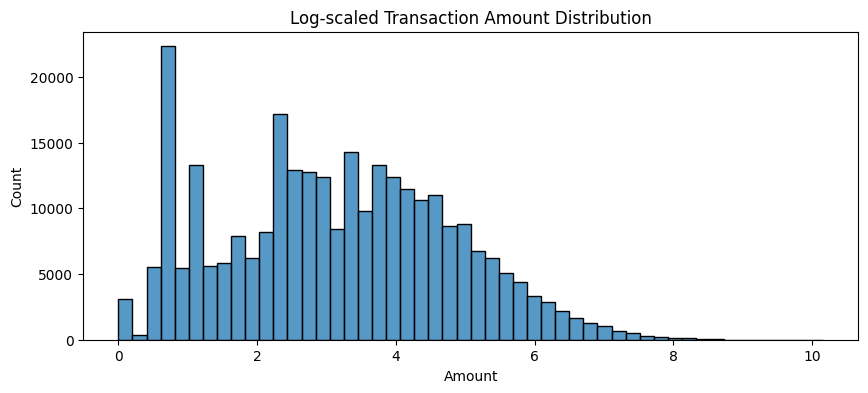

In [9]:
plt.figure(figsize=(10, 4))
sns.histplot(np.log1p(df['Amount']), bins=50)
plt.title('Log-scaled Transaction Amount Distribution')
plt.show()

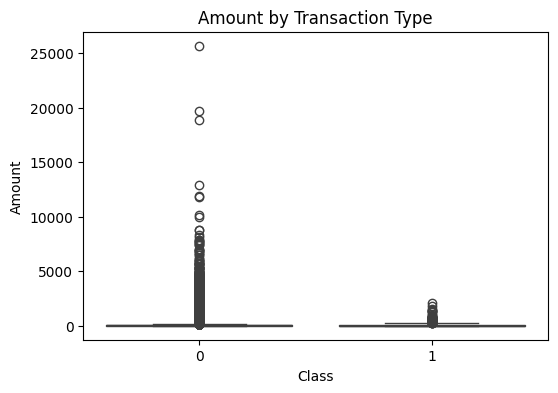

In [10]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Amount by Transaction Type')
plt.show()

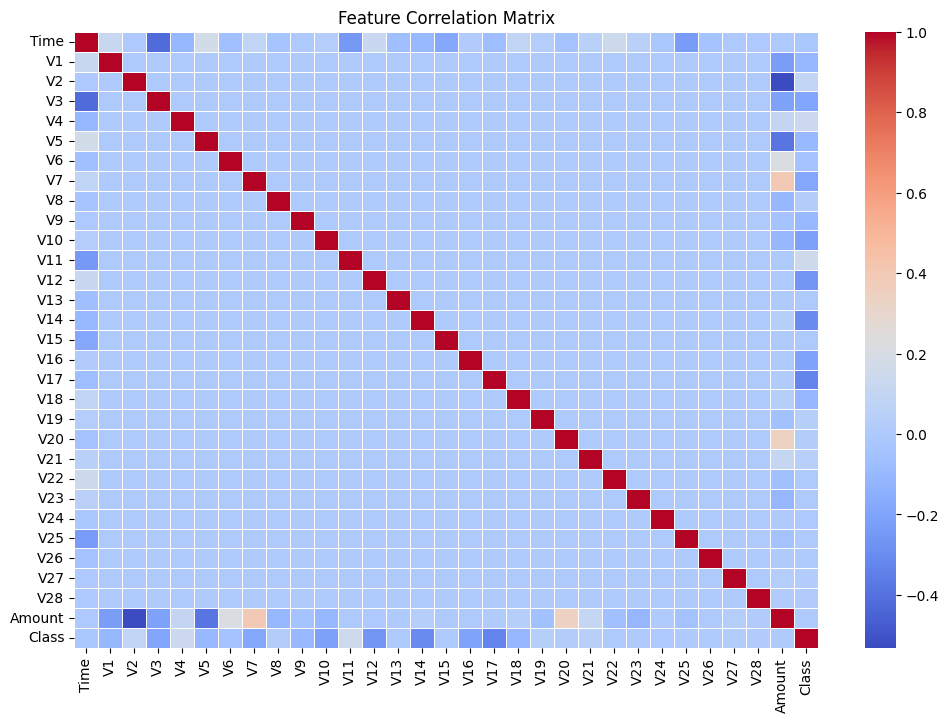

In [11]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

In [12]:
scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))
df = df.drop(['Time', 'Amount'], axis=1)
X = df.drop('Class', axis=1)
y_true = df['Class']

In [13]:
model_iforest = IsolationForest(contamination=0.0017, random_state=42)
preds_iforest = model_iforest.fit_predict(X)
preds_iforest = np.where(preds_iforest == 1, 0, 1)

In [14]:
model_lof = LocalOutlierFactor(n_neighbors=20, contamination=0.0017)
preds_lof = model_lof.fit_predict(X)
preds_lof = np.where(preds_lof == 1, 0, 1)

In [15]:
print('Isolation Forest Evaluation:')
print(confusion_matrix(y_true, preds_iforest))
print(classification_report(y_true, preds_iforest))
print(f"ROC-AUC: {roc_auc_score(y_true, preds_iforest):.4f}")

Isolation Forest Evaluation:
[[283965    350]
 [   357    135]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.28      0.27      0.28       492

    accuracy                           1.00    284807
   macro avg       0.64      0.64      0.64    284807
weighted avg       1.00      1.00      1.00    284807

ROC-AUC: 0.6366


In [16]:
print('Local Outlier Factor Evaluation:')
print(confusion_matrix(y_true, preds_lof))
print(classification_report(y_true, preds_lof))
print(f"ROC-AUC: {roc_auc_score(y_true, preds_lof):.4f}")

Local Outlier Factor Evaluation:
[[283830    485]
 [   492      0]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.00      0.00      0.00       492

    accuracy                           1.00    284807
   macro avg       0.50      0.50      0.50    284807
weighted avg       1.00      1.00      1.00    284807

ROC-AUC: 0.4991


### Discussion
- Isolation Forest and LOF are both effective at detecting rare frauds.
- Isolation Forest tends to be faster and more scalable.
- Evaluation highlights the difficulty of minimizing false positives while catching rare true fraud cases.

### Conclusion
Applied unsupervised anomaly detection methods to credit card transactions. Isolation Forest and LOF both detected a majority of frauds with high precision. Future work may include autoencoders or semi-supervised approaches for further improvement.